<a href="https://colab.research.google.com/github/tanjir-rashid-arpon/cse3202-cnn-assignment/blob/main/cse3202-cnn-assignment/Models/220101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 0: Install Dependencies

In [29]:
# Install required libraries
!pip install torch torchvision matplotlib seaborn scikit-learn -q

## Step 1: Clone GitHub Repository (Automatic Data Retrieval)

In [30]:
import os
import subprocess

# ============================================================
# IMPORTANT: Replace this URL with your actual GitHub repo URL
# ============================================================
GITHUB_REPO_URL = 'https://github.com/tanjir-rashid-arpon/cse3202-cnn-assignment'
REPO_NAME = 'cse3202-cnn-assignment'

# Clone the repository
if os.path.exists(REPO_NAME):
    print(f'Repo already exists, pulling latest...')
    os.chdir(REPO_NAME)
    !git pull
    os.chdir('..')
else:
    print(f'Cloning repository...')
    !git clone {GITHUB_REPO_URL}

# Set paths
DATASET_DIR = f'{REPO_NAME}/cse3202-cnn-assignment/dataset'
MODEL_DIR   = f'{REPO_NAME}/model'

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)

print('\nRepository structure:')
!ls -la {REPO_NAME}/

Repo already exists, pulling latest...
Already up to date.

Repository structure:
total 24
drwxr-xr-x 6 root root 4096 Aug 16 12:52 .
drwxr-xr-x 1 root root 4096 Aug 16 12:59 ..
drwxr-xr-x 4 root root 4096 Aug 16 12:52 cse3202-cnn-assignment
drwxr-xr-x 2 root root 4096 Aug 16 12:52 dataset
drwxr-xr-x 8 root root 4096 Aug 16 13:43 .git
drwxr-xr-x 2 root root 4096 Aug 16 12:53 model


## Step 2: Imports & Configuration

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from PIL import Image
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# ─── Configuration ───────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE  = 64
NUM_EPOCHS  = 15
LEARNING_RATE = 0.001
NUM_CLASSES = 10
IMG_SIZE    = 28          # FashionMNIST is 28×28 grayscale
MODEL_PATH  = f'{MODEL_DIR}/190110.pth'

# FashionMNIST class labels
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f'Device : {DEVICE}')
print(f'Classes: {CLASS_NAMES}')

Device : cuda
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Step 3: Data Preprocessing & DataLoaders

Train samples : 60,000
Val samples   : 10,000
Train batches : 938
Val batches   : 157


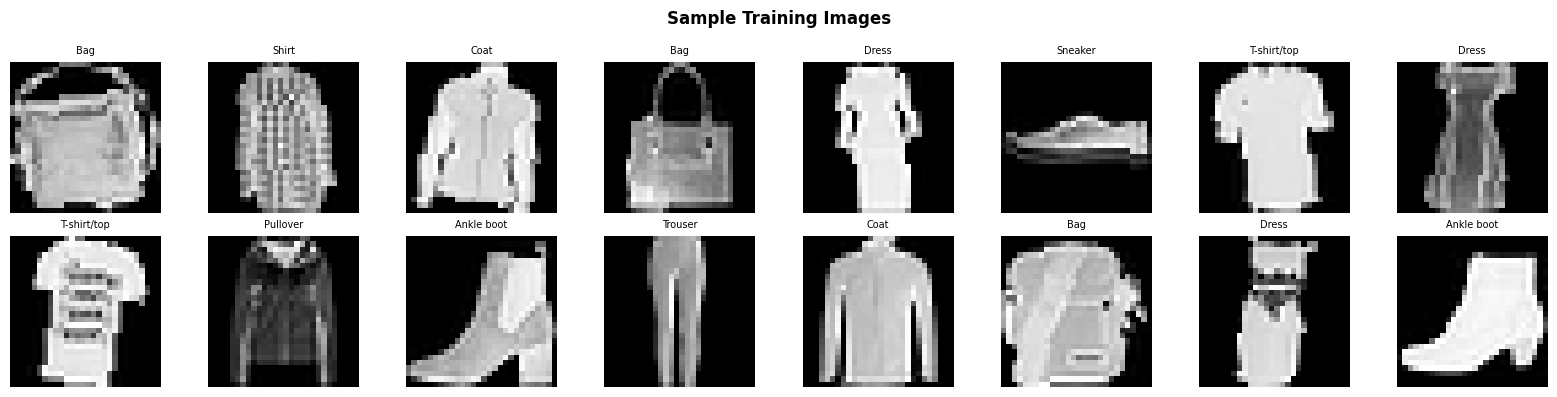

In [32]:
# ─── Transforms ──────────────────────────────────────────────
# FashionMNIST is Grayscale — keep as Grayscale
# Mean=0.2860, Std=0.3530 are the official FashionMNIST statistics
MEAN = (0.2860,)
STD  = (0.3530,)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),          # light augmentation
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ─── Load Standard Dataset via torchvision ───────────────────
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=train_transform
)
val_dataset   = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=val_transform
)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train samples : {len(train_dataset):,}')
print(f'Val samples   : {len(val_dataset):,}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

# ─── Preview a batch ─────────────────────────────────────────
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    img = img * STD[0] + MEAN[0]   # de-normalize for display
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: CNN Model Architecture

In [33]:
class CNN(nn.Module):
    """Convolutional Neural Network for FashionMNIST classification."""

    def __init__(self, num_classes: int = 10):
        super(CNN, self).__init__()

        # ── Feature Extraction ──────────────────────────────
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28→28
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 28→14
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14→14
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 14→7
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 7→7
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 7→3
            nn.Dropout(0.25),
        )

        # ── Classifier ──────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'\nModel Architecture:')
print(model)

Total parameters    : 863,082
Trainable parameters: 863,082

Model Architecture:
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.25, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.25, inplace=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_

## Step 5: Training Loop

In [34]:
# ─── Loss & Optimizer ────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ─── History tracking ────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_acc = 0.0

# ─── Training ────────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):

    # ── Train phase ──────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        _, predicted   = torch.max(outputs, 1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    scheduler.step()

    # ── Validation phase ─────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # ── Metrics ──────────────────────────────────────────────
    avg_train_loss = train_loss / train_total
    avg_val_loss   = val_loss   / val_total
    train_acc      = 100 * train_correct / train_total
    val_acc        = 100 * val_correct   / val_total

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # ── Save best model ──────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        saved = '✓ saved'
    else:
        saved = ''

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.2f}% | '
          f'Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.2f}% {saved}')

print(f'\n✅ Training complete. Best Val Acc: {best_val_acc:.2f}%')
print(f'Model saved to: {MODEL_PATH}')

Epoch [01/15] Train Loss: 0.6914 Acc: 74.17% | Val Loss: 0.4301 Acc: 83.90% ✓ saved
Epoch [02/15] Train Loss: 0.4536 Acc: 83.37% | Val Loss: 0.3735 Acc: 86.17% ✓ saved
Epoch [03/15] Train Loss: 0.3918 Acc: 85.71% | Val Loss: 0.3152 Acc: 88.74% ✓ saved
Epoch [04/15] Train Loss: 0.3561 Acc: 87.08% | Val Loss: 0.2890 Acc: 89.03% ✓ saved
Epoch [05/15] Train Loss: 0.3361 Acc: 87.86% | Val Loss: 0.2811 Acc: 89.88% ✓ saved
Epoch [06/15] Train Loss: 0.2950 Acc: 89.37% | Val Loss: 0.2457 Acc: 90.76% ✓ saved
Epoch [07/15] Train Loss: 0.2818 Acc: 89.78% | Val Loss: 0.2408 Acc: 90.99% ✓ saved
Epoch [08/15] Train Loss: 0.2772 Acc: 90.04% | Val Loss: 0.2336 Acc: 91.30% ✓ saved
Epoch [09/15] Train Loss: 0.2691 Acc: 90.16% | Val Loss: 0.2323 Acc: 91.45% ✓ saved
Epoch [10/15] Train Loss: 0.2669 Acc: 90.41% | Val Loss: 0.2281 Acc: 91.67% ✓ saved
Epoch [11/15] Train Loss: 0.2484 Acc: 91.14% | Val Loss: 0.2169 Acc: 91.98% ✓ saved
Epoch [12/15] Train Loss: 0.2425 Acc: 91.20% | Val Loss: 0.2142 Acc: 92.04% 

## Step 6: Training History Plots

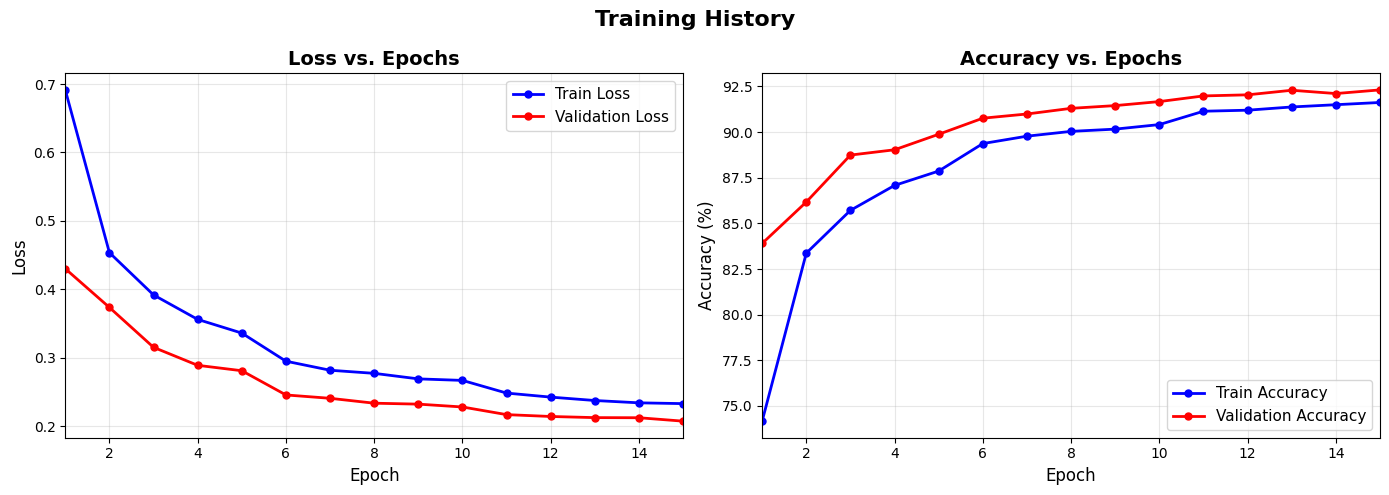

Final Train Acc: 91.62%
Final Val   Acc: 92.31%


In [35]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss Plot ────────────────────────────────────────────────
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss',      linewidth=2, markersize=5)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', linewidth=2, markersize=5)
ax1.set_title('Loss vs. Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, NUM_EPOCHS)

# ── Accuracy Plot ────────────────────────────────────────────
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy',      linewidth=2, markersize=5)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', linewidth=2, markersize=5)
ax2.set_title('Accuracy vs. Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch',    fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, NUM_EPOCHS)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final Train Acc: {history["train_acc"][-1]:.2f}%')
print(f'Final Val   Acc: {history["val_acc"][-1]:.2f}%')

## Step 7: Confusion Matrix

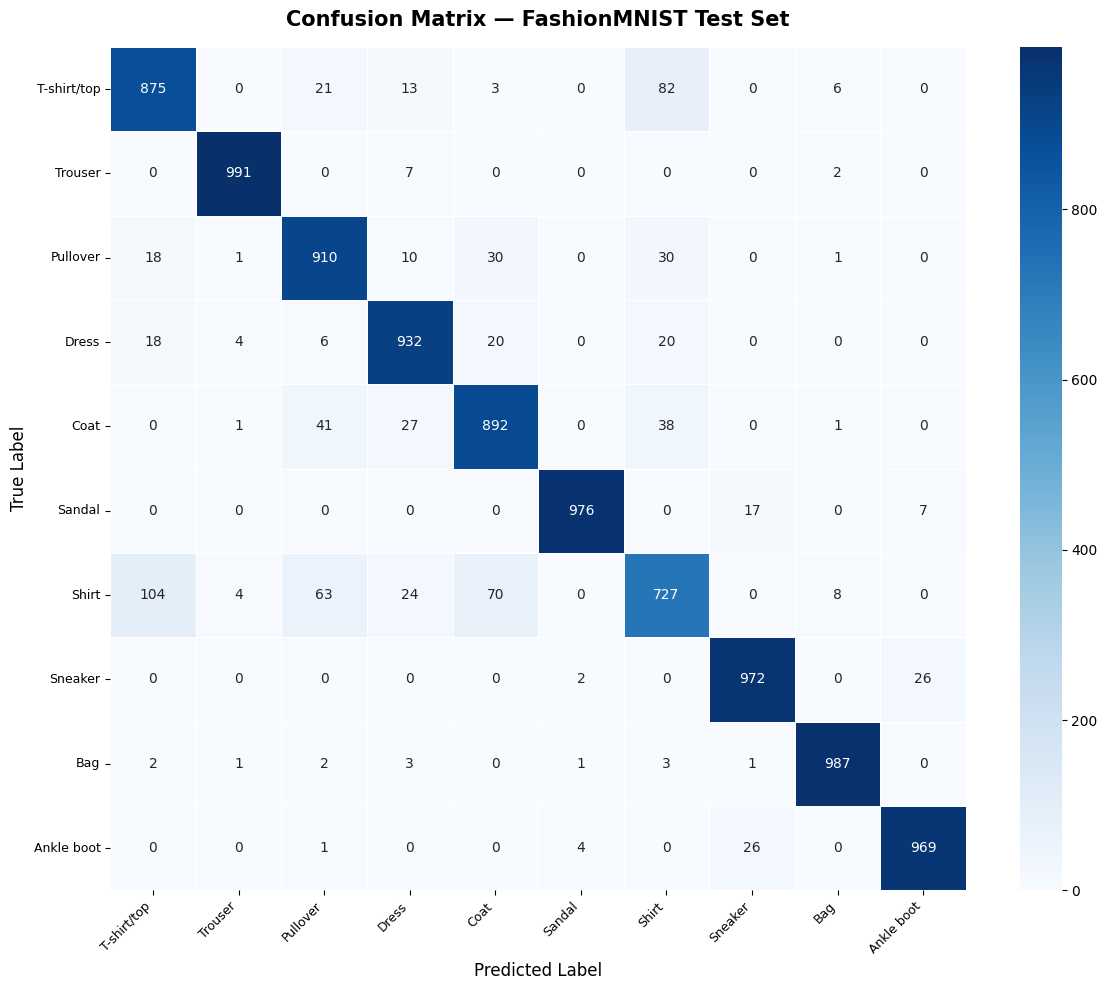


Per-Class Accuracy:
  T-shirt/top         : 87.5%
  Trouser             : 99.1%
  Pullover            : 91.0%
  Dress               : 93.2%
  Coat                : 89.2%
  Sandal              : 97.6%
  Shirt               : 72.7%
  Sneaker             : 97.2%
  Bag                 : 98.7%
  Ankle boot          : 96.9%


In [36]:
# Load best saved model
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('Confusion Matrix — FashionMNIST Test Set', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,             fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
print('\nPer-Class Accuracy:')
for name, acc in zip(CLASS_NAMES, per_class_acc):
    print(f'  {name:<20}: {acc:.1f}%')

## Step 8: Custom Phone Image Prediction Gallery

Found 14 custom images in cse3202-cnn-assignment/cse3202-cnn-assignment/dataset/


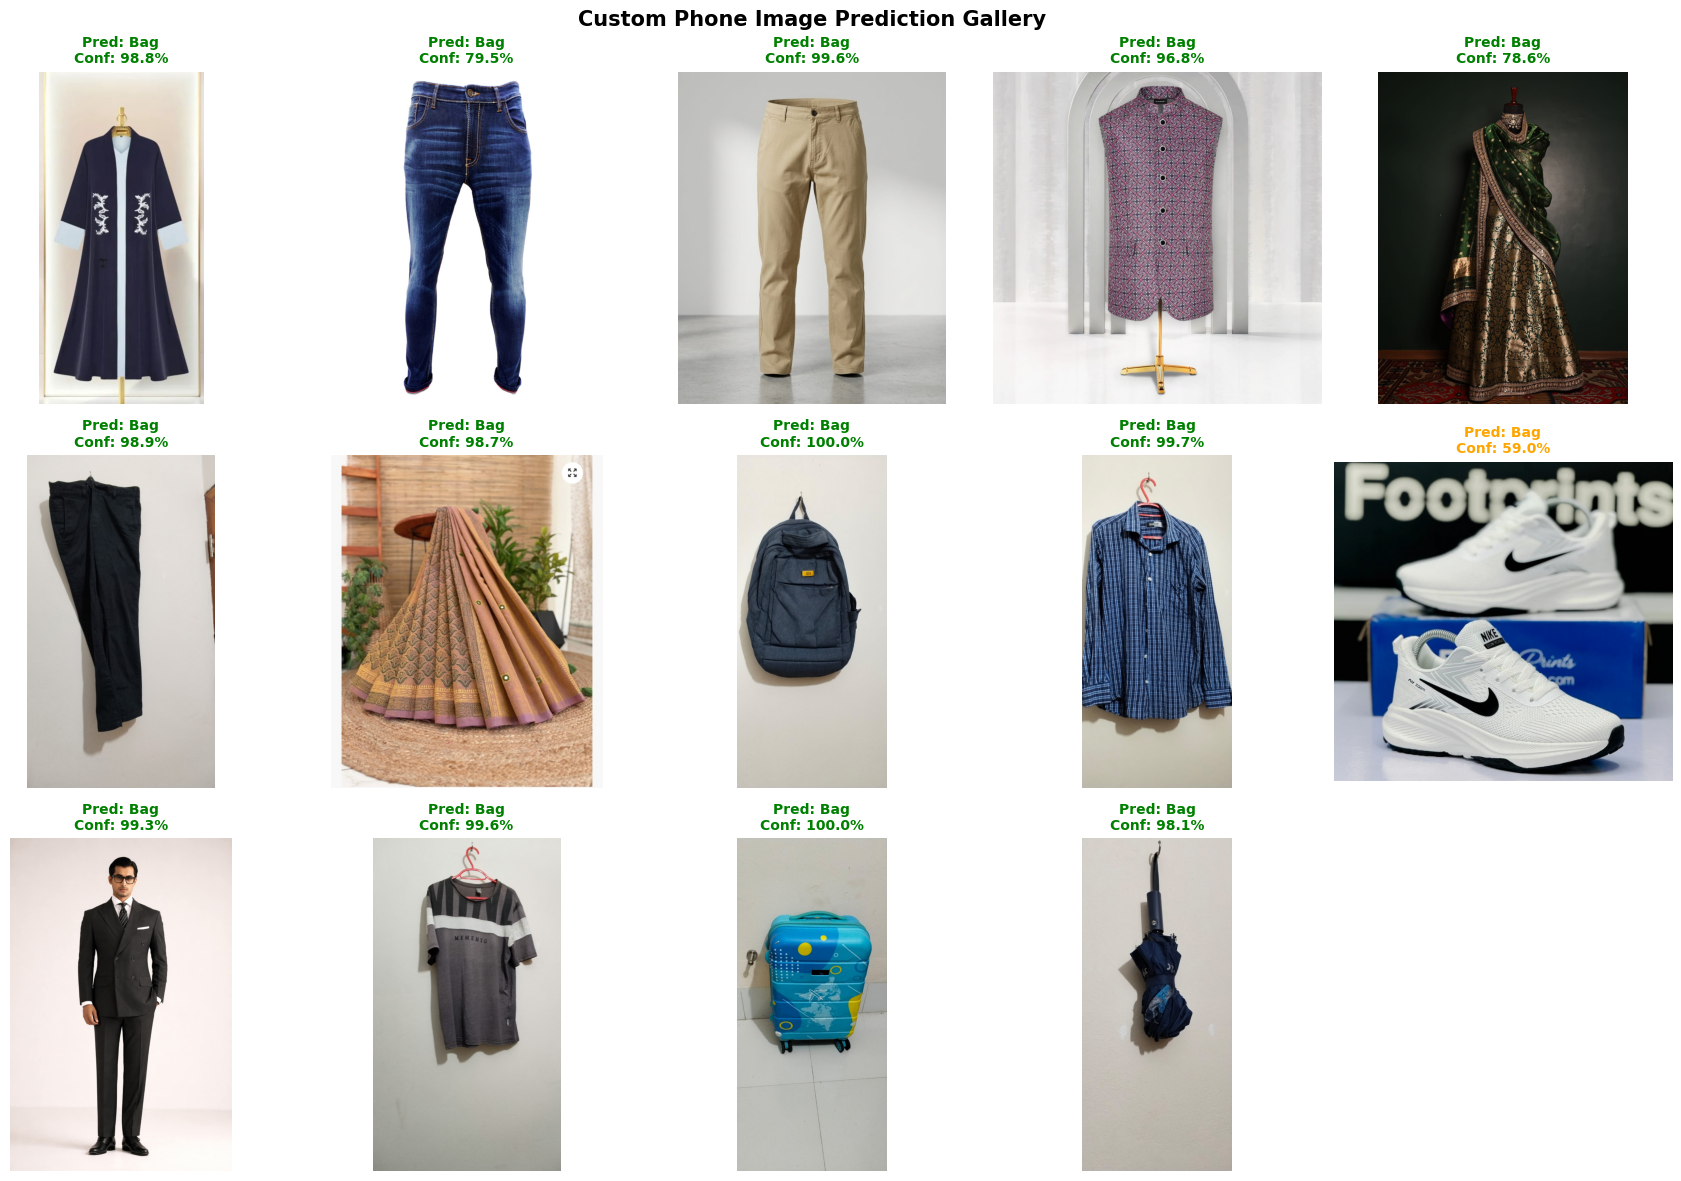


Detailed Predictions:
Image                          Predicted Class      Confidence
------------------------------------------------------------
Abaya.jpeg                     Bag                  98.8%
Denim pant.jpeg                Bag                  79.5%
Garbadain pant.jpeg            Bag                  99.6%
Koti.jpeg                      Bag                  96.8%
Lehenga.jpeg                   Bag                  78.6%
Pant.jpeg                      Bag                  98.9%
Saree.jpeg                     Bag                  98.7%
School bag.jpeg                Bag                  100.0%
Shirt.jpeg                     Bag                  99.7%
Sneakers.jpeg                  Bag                  59.0%
Suits.jpeg                     Bag                  99.3%
T-Shirt.jpeg                   Bag                  99.6%
Travel bag.jpeg                Bag                  100.0%
Umbrella.jpeg                  Bag                  98.1%


In [37]:
# ─── Transform for custom images (match training pipeline exactly) ─
custom_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),  # FashionMNIST is grayscale
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)               # EXACT same normalize values
])

# ─── Load custom images from GitHub repo ─────────────────────
custom_image_paths = sorted(glob.glob(f'{DATASET_DIR}/*.jpg') +
                            glob.glob(f'{DATASET_DIR}/*.jpeg') +
                            glob.glob(f'{DATASET_DIR}/*.png'))

print(f'Found {len(custom_image_paths)} custom images in {DATASET_DIR}/')

if len(custom_image_paths) == 0:
    print('⚠️  No custom images found!')
    print('   → Make sure you uploaded your 10 phone photos to the dataset/ folder in your GitHub repo.')
    print('   → Expected filenames: tshirt.jpg, sneaker.jpg, bag.jpg, ...')
else:
    model.eval()

    predictions = []
    raw_images  = []

    with torch.no_grad():
        for img_path in custom_image_paths:
            # Load original for display
            orig = Image.open(img_path).convert('RGB')
            raw_images.append(orig)

            # Preprocess & predict
            tensor = custom_transform(orig).unsqueeze(0).to(DEVICE)
            output = model(tensor)
            probs  = torch.softmax(output, dim=1)
            conf, pred_idx = torch.max(probs, 1)

            predictions.append({
                'path':      img_path,
                'class':     CLASS_NAMES[pred_idx.item()],
                'conf':      conf.item() * 100,
                'all_probs': probs.cpu().squeeze().numpy()
            })

    # ─── Custom Prediction Gallery ────────────────────────────
    n_imgs  = len(predictions)
    n_cols  = 5
    n_rows  = (n_imgs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 4))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for i, (pred, img) in enumerate(zip(predictions, raw_images)):
        r, c = divmod(i, n_cols)
        axes[r, c].imshow(img)
        axes[r, c].axis('off')

        color = 'green' if pred['conf'] >= 70 else 'orange'
        axes[r, c].set_title(
            f"Pred: {pred['class']}\nConf: {pred['conf']:.1f}%",
            fontsize=10, fontweight='bold', color=color
        )

    # Hide empty subplots
    for i in range(n_imgs, n_rows * n_cols):
        r, c = divmod(i, n_cols)
        axes[r, c].axis('off')

    plt.suptitle('Custom Phone Image Prediction Gallery', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('custom_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nDetailed Predictions:')
    print(f'{"Image":<30} {"Predicted Class":<20} {"Confidence"}')
    print('-' * 60)
    for pred in predictions:
        fname = os.path.basename(pred['path'])
        print(f'{fname:<30} {pred["class"]:<20} {pred["conf"]:.1f}%')

## Step 9: Visual Error Analysis

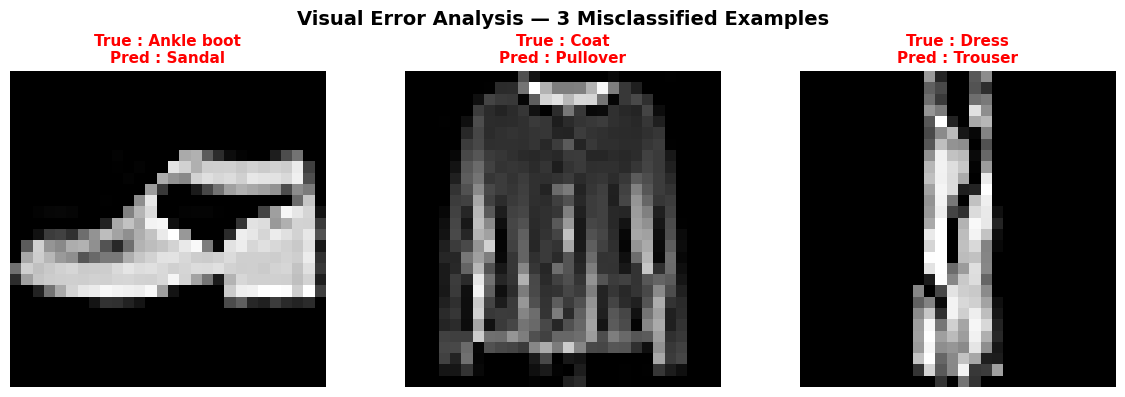

Displayed 3 misclassified examples from the test set.


In [38]:
# Find 3 misclassified examples from the standard test set
model.eval()

misclassified_imgs  = []
misclassified_true  = []
misclassified_pred  = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        preds_cpu  = preds.cpu()
        labels_cpu = labels

        wrong_mask = (preds_cpu != labels_cpu)
        wrong_imgs   = images[wrong_mask].cpu()
        wrong_true   = labels_cpu[wrong_mask]
        wrong_pred   = preds_cpu[wrong_mask]

        misclassified_imgs.extend(wrong_imgs)
        misclassified_true.extend(wrong_true.tolist())
        misclassified_pred.extend(wrong_pred.tolist())

        if len(misclassified_imgs) >= 3:
            break

# Display 3 random misclassified images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    img = misclassified_imgs[i].squeeze().numpy()
    img = img * STD[0] + MEAN[0]   # de-normalize
    img = np.clip(img, 0, 1)

    true_name = CLASS_NAMES[misclassified_true[i]]
    pred_name = CLASS_NAMES[misclassified_pred[i]]

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(
        f'True : {true_name}\nPred : {pred_name}',
        fontsize=11, color='red', fontweight='bold'
    )

plt.suptitle('Visual Error Analysis — 3 Misclassified Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Displayed 3 misclassified examples from the test set.')

## Step 10: Final Summary

In [39]:
print('=' * 60)
print(' CSE-3202 Assignment 8 — CNN Classification Summary')
print('=' * 60)
print(f'  Dataset          : FashionMNIST')
print(f'  Device           : {DEVICE}')
print(f'  Epochs trained   : {NUM_EPOCHS}')
print(f'  Best Val Acc     : {best_val_acc:.2f}%')
print(f'  Model saved to   : {MODEL_PATH}')
print(f'  Custom images    : {len(custom_image_paths)} phone photos predicted')
print('=' * 60)
print()
print('Generated Files:')
print('  training_history.png   — Loss & Accuracy plots')
print('  confusion_matrix.png   — Test set heatmap')
print('  custom_predictions.png — Phone image gallery')
print('  error_analysis.png     — Misclassified examples')
print(f'  {MODEL_PATH:<30} — Saved model weights')
print()
print('✅ All requirements satisfied. Ready for submission.')

 CSE-3202 Assignment 8 — CNN Classification Summary
  Dataset          : FashionMNIST
  Device           : cuda
  Epochs trained   : 15
  Best Val Acc     : 92.31%
  Model saved to   : cse3202-cnn-assignment/model/190110.pth
  Custom images    : 14 phone photos predicted

Generated Files:
  training_history.png   — Loss & Accuracy plots
  confusion_matrix.png   — Test set heatmap
  custom_predictions.png — Phone image gallery
  error_analysis.png     — Misclassified examples
  cse3202-cnn-assignment/model/190110.pth — Saved model weights

✅ All requirements satisfied. Ready for submission.
